## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from transformers import GPT2Tokenizer, GPT2LMHeadModel, DataCollatorForLanguageModeling, Trainer, TrainingArguments, pipeline

from sklearn.model_selection import train_test_split

from datasets import Dataset

a:\github_projects\poem_generation\gpt_tuning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

In [2]:
data = pd.read_csv('robert_frost_collection.csv')
data.head()

,Name,Content,Collection,Year of Publication
0,NaN,NaN,NaN,NaN
1,Stopping by Woods on a Snowy Evening,Whose woods these are I think I know. \nHis ...,New Hampshire,1923.0
2,Fire and Ice,"Some say the world will end in fire,\nSome say...",New Hampshire,1923.0
3,The Aim was Song,Before man came to blow it right\nThe wind onc...,New Hampshire,1923.0
4,The Need of Being Versed in Country Things,The house had gone to bring again\nTo the midn...,New Hampshire,1923.0


In [3]:
data.dropna(inplace=True)
data.shape

(107, 4)

In [4]:
data.isna().sum()

Name                   0
Content                0
Collection             0
Year of Publication    0
dtype: int64

In [5]:
data['word_count'] = data['Content'].apply(lambda x: len(str(x).split()))
print(data['word_count'].describe())

count     107.000000
mean      392.373832
std       519.226920
min        25.000000
25%       115.500000
50%       179.000000
75%       376.000000
max      3191.000000
Name: word_count, dtype: float64


In [6]:
data.head(10)

,Name,Content,Collection,Year of Publication,word_count
1,Stopping by Woods on a Snowy Evening,Whose woods these are I think I know. \nHis ...,New Hampshire,1923.0,108
2,Fire and Ice,"Some say the world will end in fire,\nSome say...",New Hampshire,1923.0,51
3,The Aim was Song,Before man came to blow it right\nThe wind onc...,New Hampshire,1923.0,113
4,The Need of Being Versed in Country Things,The house had gone to bring again\nTo the midn...,New Hampshire,1923.0,189
5,I Will Sing You One O,It was long I lay\nAwake that night\nWishing t...,New Hampshire,1923.0,289
6,"For Once, Then, Something",Others taunt me with having knelt at well-curb...,New Hampshire,1923.0,126
7,The Onset,"Always the same, when on a fated night\nAt las...",New Hampshire,1923.0,184
8,Nothing Gold Can Stay,"Nature’s first green is gold,\nHer hardest hue...",New Hampshire,1923.0,40
9,Tree at my Window,"Tree at my window, window tree,\nMy sash is lo...",West-Running Book,1928.0,106
10,Acquainted with the Night,I have been one acquainted with the night.\nI ...,West-Running Book,1928.0,108


## Pre-processing

In [7]:
data = data.drop_duplicates()

data.shape

(107, 5)

In [8]:
data.columns

Index(['Name ', 'Content', 'Collection', 'Year of Publication', 'word_count'], dtype='object')

In [9]:
data.drop(data[['Name ', 'Collection', 'Year of Publication', 'word_count']], axis=1, inplace=True)

In [10]:
data.head()

,Content
1,Whose woods these are I think I know. \nHis ...
2,"Some say the world will end in fire,\nSome say..."
3,Before man came to blow it right\nThe wind onc...
4,The house had gone to bring again\nTo the midn...
5,It was long I lay\nAwake that night\nWishing t...


In [11]:
formatted_poems = []

for poem in data["Content"]:
    formatted_poems.append(
        "<|startofpoem|>\n"
        + poem.strip()
        + "\n<|endofpoem|>"
    )

corpus = "\n\n".join(formatted_poems)
print(f"Formatted Poems\n{formatted_poems}")

Formatted Poems
['<|startofpoem|>\nWhose woods these are I think I know.   \nHis house is in the village though;   \nHe will not see me stopping here   \nTo watch his woods fill up with snow.   \nMy little horse must think it queer   \nTo stop without a farmhouse near   \nBetween the woods and frozen lake   \nThe darkest evening of the year.   \nHe gives his harness bells a shake   \nTo ask if there is some mistake.   \nThe only other sound’s the sweep   \nOf easy wind and downy flake.   \nThe woods are lovely, dark and deep,   \nBut I have promises to keep,   \nAnd miles to go before I sleep,   \nAnd miles to go before I sleep.\n<|endofpoem|>', '<|startofpoem|>\nSome say the world will end in fire,\nSome say in ice.\nFrom what I’ve tasted of desire\nI hold with those who favor fire.\nBut if it had to perish twice,\nI think I know enough of hate\nTo say that for destruction ice\nIs also great\nAnd would suffice.\n<|endofpoem|>', '<|startofpoem|>\nBefore man came to blow it right\nThe w

In [12]:
formatted_poems

['<|startofpoem|>\nWhose woods these are I think I know.   \nHis house is in the village though;   \nHe will not see me stopping here   \nTo watch his woods fill up with snow.   \nMy little horse must think it queer   \nTo stop without a farmhouse near   \nBetween the woods and frozen lake   \nThe darkest evening of the year.   \nHe gives his harness bells a shake   \nTo ask if there is some mistake.   \nThe only other sound’s the sweep   \nOf easy wind and downy flake.   \nThe woods are lovely, dark and deep,   \nBut I have promises to keep,   \nAnd miles to go before I sleep,   \nAnd miles to go before I sleep.\n<|endofpoem|>',
 '<|startofpoem|>\nSome say the world will end in fire,\nSome say in ice.\nFrom what I’ve tasted of desire\nI hold with those who favor fire.\nBut if it had to perish twice,\nI think I know enough of hate\nTo say that for destruction ice\nIs also great\nAnd would suffice.\n<|endofpoem|>',
 '<|startofpoem|>\nBefore man came to blow it right\nThe wind once blew 

#### Train-Test Split

In [13]:
train_set, test_set = train_test_split(formatted_poems, test_size=0.1, random_state=42)

In [14]:
train_set = Dataset.from_dict({"Content": train_set})
test_set = Dataset.from_dict({"Content": test_set})

In [15]:
print(len(train_set[0]["Content"]))

1851


## GPT-2 Small Fine-tuning (ZERO Layers Frozen)

#### Loading tokenizer, model & data collator

In [16]:
output_dir = "GPT2Small"

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

tokenizer.pad_token = tokenizer.eos_token

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8907.40it/s]


#### GPT-2 Small Number of Layers

In [17]:
model.config.n_layer

12

#### Training

In [18]:
def tokenize_data(data):
    return tokenizer(data['Content'], truncation=True, max_length=1000, padding="max_length")

tokenized_train_set = train_set.map(tokenize_data, batched=True, remove_columns=train_set.column_names)
tokenized_test_set = test_set.map(tokenize_data, batched=True, remove_columns=test_set.column_names)

Map: 100%|██████████| 11/11 [00:00<00:00, 821.23 examples/s]


In [19]:
def set_args(epochs, lr):
    return TrainingArguments(output_dir=output_dir,
                             num_train_epochs=epochs,
                             per_device_train_batch_size=2,
                             per_device_eval_batch_size=2,
                             eval_strategy="epoch",
                             save_strategy="epoch",
                             save_total_limit=2,
                             logging_steps=5,
                             learning_rate=lr,
                             weight_decay=0.01,
                             fp16=True,
                             gradient_accumulation_steps=8,
                             report_to='none')

In [20]:
trainer = Trainer(model=model, args=set_args(10, 5e-5), train_dataset=tokenized_train_set, eval_dataset=tokenized_test_set, data_collator=data_collator)

trainer.train()

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,4.045471,3.809233
2,3.814754,3.697082
3,3.674587,3.664078
4,3.597787,3.649904
5,3.405950,3.638858
6,3.373131,3.635212
7,3.382967,3.631783
8,3.433806,3.632864
9,3.267604,3.631176
10,3.310395,3.630814


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.95it/s]


('GPT2Small\\tokenizer_config.json', 'GPT2Small\\tokenizer.json')

#### Training Learning Curve

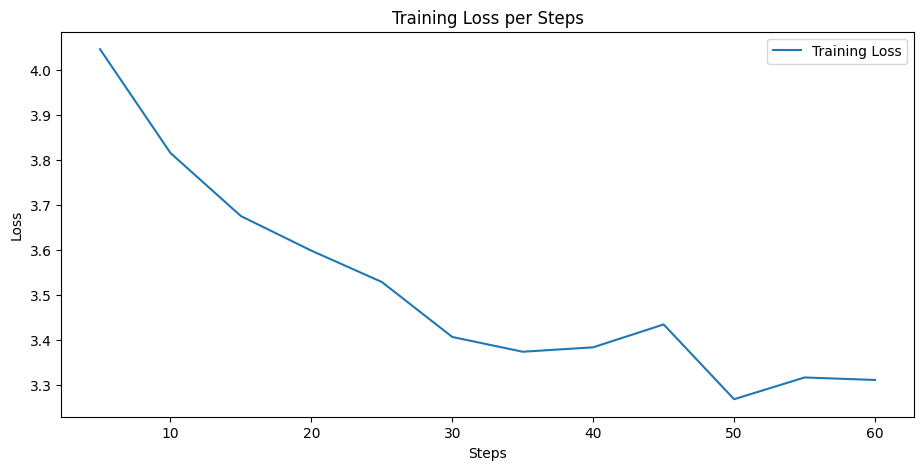

In [21]:
logs = trainer.state.log_history

steps = [log["step"] for log in logs if "loss" in log]
losses = [log["loss"] for log in logs if "loss" in log]

plt.figure(figsize=(11, 5))

plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss per Steps")
plt.legend()
plt.show()

#### Test Generation

In [22]:
generator = pipeline(
    "text-generation",
    model=output_dir,
    tokenizer=output_dir
)

print(
    generator(
        """<|startofpoem|>\nThe woods""",
        max_new_tokens=120,
        do_sample=True,
        temperature=0.9
    )[0]["generated_text"]
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12496.37it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corr

<|startofpoem|>
The woods were still dark,
And some birds flew and some flailed;
But one was still in the woods
And singing,
And in the trees,
On a sad song;
He was singing in a great river.
The song of the woods was the song of the wild
And when he heard
Of the wild birds,
He did not know what song it was.
A woman with a wreath stood
Heard a long song in the spring,
And sang in a voice of white to the water.
They were all together and singing
The song


## GPT-2 Small Fine-tunning (Last 2 Layers unfrozen)

In [24]:
output_dir = "GPT2Small_FrozenLayers"

frozen_model = GPT2LMHeadModel.from_pretrained("gpt2")
frozen_model.load_state_dict(model.state_dict())

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 19997.97it/s]


<All keys matched successfully>

#### Unfreezing the last 2 layers

In [25]:
# Freeze first 10 layers
for i in range(10):
    for param in frozen_model.transformer.h[i].parameters():
        param.requires_grad = False

# Unfreeze last 2 layers
for i in range(10, 12):
    for param in frozen_model.transformer.h[i].parameters():
        param.requires_grad = True

In [26]:
for name, param in frozen_model.named_parameters():
    print(name, param.requires_grad)

transformer.wte.weight True
transformer.wpe.weight True
transformer.h.0.ln_1.weight False
transformer.h.0.ln_1.bias False
transformer.h.0.attn.c_attn.weight False
transformer.h.0.attn.c_attn.bias False
transformer.h.0.attn.c_proj.weight False
transformer.h.0.attn.c_proj.bias False
transformer.h.0.ln_2.weight False
transformer.h.0.ln_2.bias False
transformer.h.0.mlp.c_fc.weight False
transformer.h.0.mlp.c_fc.bias False
transformer.h.0.mlp.c_proj.weight False
transformer.h.0.mlp.c_proj.bias False
transformer.h.1.ln_1.weight False
transformer.h.1.ln_1.bias False
transformer.h.1.attn.c_attn.weight False
transformer.h.1.attn.c_attn.bias False
transformer.h.1.attn.c_proj.weight False
transformer.h.1.attn.c_proj.bias False
transformer.h.1.ln_2.weight False
transformer.h.1.ln_2.bias False
transformer.h.1.mlp.c_fc.weight False
transformer.h.1.mlp.c_fc.bias False
transformer.h.1.mlp.c_proj.weight False
transformer.h.1.mlp.c_proj.bias False
transformer.h.2.ln_1.weight False
transformer.h.2.ln_1.b

#### Training

In [27]:
trainer = Trainer(model=frozen_model, args=set_args(10, 5e-5), train_dataset=tokenized_train_set, eval_dataset=tokenized_test_set, data_collator=data_collator)

trainer.train()

frozen_model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

Epoch,Training Loss,Validation Loss
1,3.257932,3.637258
2,3.252249,3.644461
3,3.225115,3.650274
4,3.236991,3.656075
5,3.144066,3.661524
6,3.139617,3.665408
7,3.185145,3.669308
8,3.254013,3.671620
9,3.115482,3.673045
10,3.180203,3.673296


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.36it/s]


('GPT2Small_FrozenLayers\\tokenizer_config.json',
 'GPT2Small_FrozenLayers\\tokenizer.json')

#### Training Learning Curve

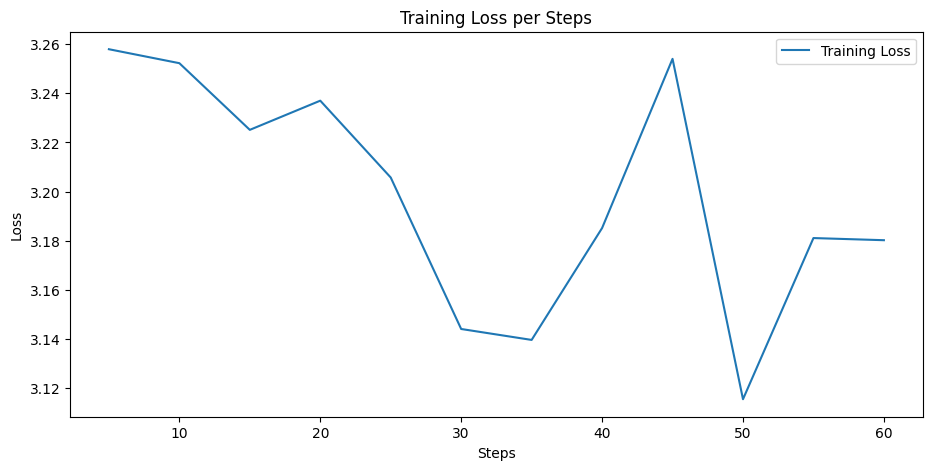

In [28]:
logs = trainer.state.log_history

steps = [log["step"] for log in logs if "loss" in log]
losses = [log["loss"] for log in logs if "loss" in log]

plt.figure(figsize=(11, 5))

plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss per Steps")
plt.legend()
plt.show()

#### Test Generation

In [29]:
generator = pipeline(
    "text-generation",
    model=output_dir,
    tokenizer=output_dir
)

print(
    generator(
        """<|startofpoem|>\nThe woods""",
        max_new_tokens=120,
        do_sample=True,
        temperature=0.9
    )[0]["generated_text"]
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7741.66it/s]
[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|startofpoem|>
The woods were still dark,
And some birds flew and some faded
In the breeze,
And some birds glided and some faded
In the breeze,
They had not turned to flight,
And some birds flew and some faded
In the breeze,
They had not turned to flight
But rested,
And some birds flew and some faded
In the breeze,
They had not turned to flight
But sat, and some birds flew
And some faded
In the breeze,
They had not turned to flight
But rested,
And some birds flew and some faded



## GPT-2 Medium Fine-tunning (Last 4 layers unfrozen)

#### GPT-2 Medium Fine Tunning (Last Four Layers unfrozen)

In [30]:
output_dir = "GPT2Medium_FrozenLayers"

tokenizer_med = GPT2Tokenizer.from_pretrained("gpt2-medium")
model_med = GPT2LMHeadModel.from_pretrained("gpt2-medium")

tokenizer_med.pad_token = tokenizer_med.eos_token

data_collator2 = DataCollatorForLanguageModeling(tokenizer=tokenizer_med, mlm=False)

a:\github_projects\poem_generation\gpt_tuning\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LEGION\.cache\huggingface\hub\models--gpt2-medium. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 292/292 [00:00<00:00, 10672.62it/s]


#### GPT-2 Medium Number of Layers

In [32]:
model_med.config.n_layer

24

In [33]:
def tokenize_data(data):
    return tokenizer_med(data['Content'], truncation=True, max_length=1000, padding="max_length")

tokenized_train_set = train_set.map(tokenize_data, batched=True, remove_columns=train_set.column_names)
tokenized_test_set = test_set.map(tokenize_data, batched=True, remove_columns=test_set.column_names)

Map: 100%|██████████| 11/11 [00:00<00:00, 566.26 examples/s]


#### Unfreezing the last 4 layers

In [35]:
# Freeze first 10 layers
for i in range(20):
    for param in model_med.transformer.h[i].parameters():
        param.requires_grad = False

# Unfreeze last 2 layers
for i in range(20, 24):
    for param in model_med.transformer.h[i].parameters():
        param.requires_grad = True

In [36]:
for name, param in model_med.named_parameters():
    print(name, param.requires_grad)

transformer.wte.weight True
transformer.wpe.weight True
transformer.h.0.ln_1.weight False
transformer.h.0.ln_1.bias False
transformer.h.0.attn.c_attn.weight False
transformer.h.0.attn.c_attn.bias False
transformer.h.0.attn.c_proj.weight False
transformer.h.0.attn.c_proj.bias False
transformer.h.0.ln_2.weight False
transformer.h.0.ln_2.bias False
transformer.h.0.mlp.c_fc.weight False
transformer.h.0.mlp.c_fc.bias False
transformer.h.0.mlp.c_proj.weight False
transformer.h.0.mlp.c_proj.bias False
transformer.h.1.ln_1.weight False
transformer.h.1.ln_1.bias False
transformer.h.1.attn.c_attn.weight False
transformer.h.1.attn.c_attn.bias False
transformer.h.1.attn.c_proj.weight False
transformer.h.1.attn.c_proj.bias False
transformer.h.1.ln_2.weight False
transformer.h.1.ln_2.bias False
transformer.h.1.mlp.c_fc.weight False
transformer.h.1.mlp.c_fc.bias False
transformer.h.1.mlp.c_proj.weight False
transformer.h.1.mlp.c_proj.bias False
transformer.h.2.ln_1.weight False
transformer.h.2.ln_1.b

#### Training

In [37]:
trainer = Trainer(model=model_med, args=set_args(10, 5e-5), train_dataset=tokenized_train_set, eval_dataset=tokenized_test_set, data_collator=data_collator2)

trainer.train()

model_med.save_pretrained(output_dir)
tokenizer_med.save_pretrained(output_dir)

Epoch,Training Loss,Validation Loss
1,3.821230,3.666087
2,3.741736,3.613529
3,3.677527,3.577843
4,3.618671,3.554681
5,3.458515,3.545970
6,3.422129,3.536321
7,3.438478,3.532213
8,3.522057,3.529506
9,3.335683,3.529008
10,3.413768,3.529531


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s]


('GPT2Medium_FrozenLayers\\tokenizer_config.json',
 'GPT2Medium_FrozenLayers\\tokenizer.json')

#### Training Learning Curve

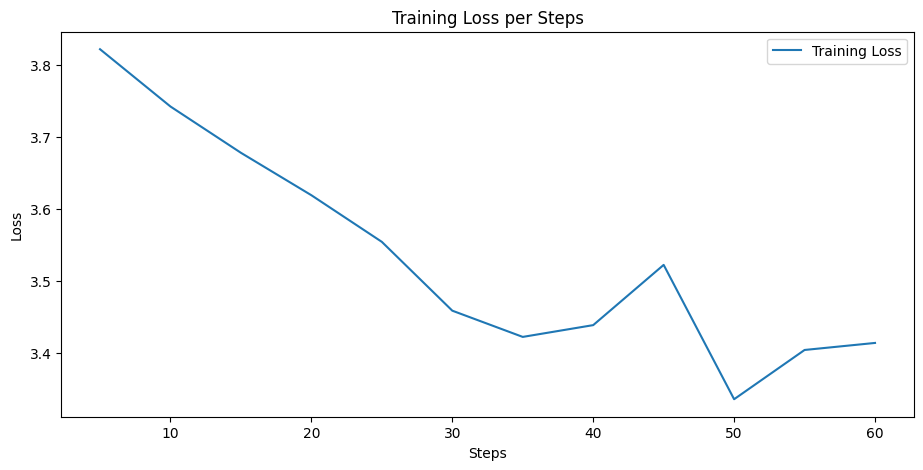

In [38]:
logs = trainer.state.log_history

steps = [log["step"] for log in logs if "loss" in log]
losses = [log["loss"] for log in logs if "loss" in log]

plt.figure(figsize=(11, 5))

plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss per Steps")
plt.legend()
plt.show()

#### Test Generation

In [39]:
generator = pipeline(
    "text-generation",
    model=output_dir,
    tokenizer=output_dir
)

print(
    generator(
        """<|startofpoem|>\nThe woods""",
        max_new_tokens=120,
        do_sample=True,
        temperature=0.9
    )[0]["generated_text"]
)

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 5856.85it/s]
[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|startofpoem|>
The woods were still full of the sound of the birds chirping as I walked through them, but once I was gone they were gone, they moved on their own accord.
I was glad to have changed into my bag and headed for the door to turn on the light. I turned and looked out the window until it was dark again and when I looked back I saw the moon just beginning to come back.
I heard the clatter of the door and turned. I heard something fall somewhere behind me and then everything just turned black. It sounded like a woman as she fell and I ran after
